# ML-матчинг сотрудников: обучаемый классификатор пар

Задача из ТЗ (разделы 1.3, 15): сопоставить записи из разных оценочных источников
с эталоном сотрудников, в т.ч. **без email** и при наличии **однофамильцев**.

В основном пайплайне (`src/`) матчинг сделан правилами. Здесь - **обучаемая
модель**: те же rapidfuzz-фичи превращаются в feature-вектор, на котором
обучается классификатор пар (match / not-match) с честными метриками,
калибровкой вероятностей и анализом важности признаков.

Это и есть ML-часть тестового: train/test, сравнение моделей, ROC/PR-AUC,
calibration, permutation importance, выбор порога под бизнес-режим.

## 1. Данные: размеченные пары с hard negatives

Реальных файлов всего 8 - обучать не на чем. Поэтому генерируем эталон
сотрудников и зашумлённые записи источников (опечатки, ё/е, перестановка токенов,
**потеря отчества** и **отсутствие email** - ровно как в отчётах ЭРА/SkillCode).

Ключевой приём - **hard negatives**: в отрицательные пары берём не случайных людей,
а однофамильцев и похожих по ФИО. Без этого модель учится тривиально и проваливается
на реальных однофамильцах (Абызов Е.И. vs Абызов Е.О.).

In [1]:
import sys
sys.path.insert(0, '.')
import numpy as np
from dataset import build_dataset

X, y, names, meta = build_dataset(n_emp=400, neg_per_pos=3, seed=11)
X, y = np.array(X, float), np.array(y, int)
print(f'Пар: {len(y)} | positive: {y.sum()} ({y.mean():.1%}) | фич: {X.shape[1]}')
print('Фичи:', names)

Пар: 3148 | positive: 787 (25.0%) | фич: 10
Фичи: ['fio_token_set', 'fio_token_sort', 'fio_jaro_winkler', 'fio_levenshtein', 'fio_overlap', 'fio_containment', 'email_exact', 'login_match', 'manager_match', 'len_ratio']


## 2. Признаки пары

10 фич на rapidfuzz (все в [0,1]):
- сходство ФИО: token_set, token_sort, Jaro-Winkler, Levenshtein
- структура токенов: overlap (Жаккар), **containment** (одно ФИО - подмножество другого)
- точное совпадение email
- логин - локальная часть email (с транслитом)
- совпадение руководителя
- отношение длин ФИО

Один и тот же `pair_features` используется при обучении и в инференсе - нет
train/serve skew.

In [2]:
import pandas as pd
df = pd.DataFrame(X, columns=names); df['label'] = y
df.groupby('label').mean().round(3).T

label,0,1
fio_token_set,0.828,0.967
fio_token_sort,0.732,0.917
fio_jaro_winkler,0.807,0.934
fio_levenshtein,0.550,0.789
fio_overlap,0.418,0.748
fio_containment,0.603,0.867
email_exact,0.037,0.454
login_match,0.210,0.286
manager_match,0.233,0.526
len_ratio,0.872,0.903


## 3. Обучение и сравнение: LogReg vs GradientBoosting

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

models = {
    'logreg': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'gboost': GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42),
}
proba = {}
for name, mdl in models.items():
    mdl.fit(X_tr, y_tr)
    p = mdl.predict_proba(X_te)[:,1]; proba[name] = p
    print(f"{name:8s} ROC-AUC={roc_auc_score(y_te,p):.4f}  "
          f"PR-AUC={average_precision_score(y_te,p):.4f}  "
          f"F1@0.5={f1_score(y_te,(p>=0.5).astype(int)):.3f}")

logreg   ROC-AUC=0.9540  PR-AUC=0.9020  F1@0.5=0.832


gboost   ROC-AUC=0.9963  PR-AUC=0.9885  F1@0.5=0.962


GradientBoosting заметно сильнее: он ловит нелинейные взаимодействия фич -
например "email нет, но логин совпал с локальной частью И руководитель совпал" -
которые линейная модель сложить не может. LogReg остаётся хорошим интерпретируемым
baseline.

## 4. ROC и Precision-Recall

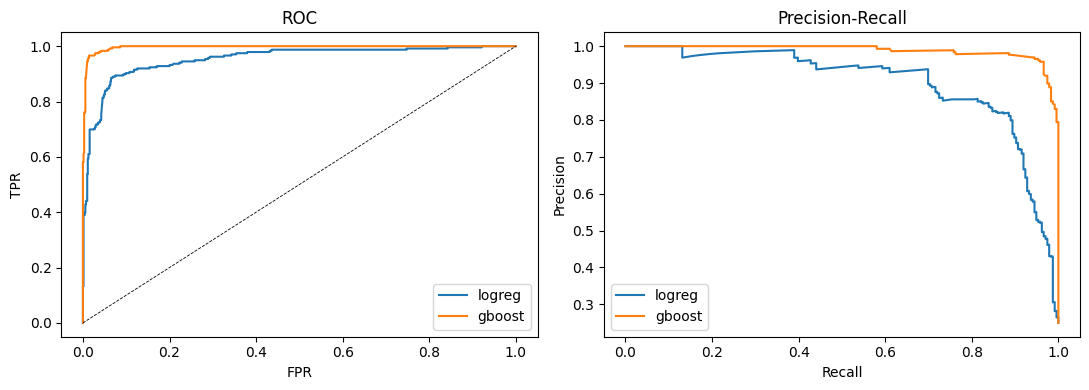

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fig, ax = plt.subplots(1, 2, figsize=(11,4))
for name, p in proba.items():
    fpr,tpr,_ = roc_curve(y_te,p); ax[0].plot(fpr,tpr,label=name)
    pr,rc,_ = precision_recall_curve(y_te,p); ax[1].plot(rc,pr,label=name)
ax[0].plot([0,1],[0,1],'k--',lw=.6); ax[0].set(title='ROC',xlabel='FPR',ylabel='TPR'); ax[0].legend()
ax[1].set(title='Precision-Recall',xlabel='Recall',ylabel='Precision'); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Калибровка вероятностей

Для осмысленного порога вероятности должны быть калиброваны: предсказанные
0.9 должны соответствовать ~90% настоящих матчей. Применяем isotonic-калибровку.

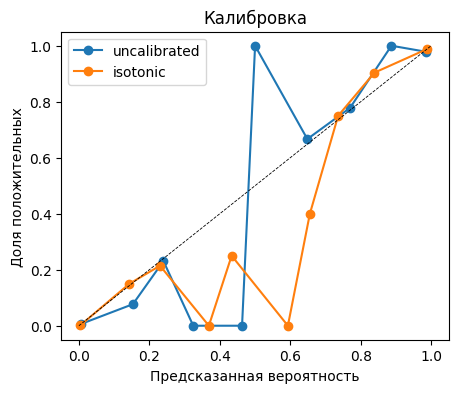

In [5]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best = 'gboost'
cal = CalibratedClassifierCV(models[best], method='isotonic', cv=5).fit(X_tr, y_tr)
p_cal = cal.predict_proba(X_te)[:,1]

plt.figure(figsize=(5,4))
for lab,p in [('uncalibrated',proba[best]),('isotonic',p_cal)]:
    fr,mp = calibration_curve(y_te,p,n_bins=10); plt.plot(mp,fr,'o-',label=lab)
plt.plot([0,1],[0,1],'k--',lw=.6)
plt.xlabel('Предсказанная вероятность'); plt.ylabel('Доля положительных')
plt.legend(); plt.title('Калибровка'); plt.show()

На небольшом тесте кривая в середине шумная, но в высоковероятной зоне
(где мы и принимаем матч) калиброванная модель ближе к диагонали - именно там это важно.

## 6. Важность признаков (permutation importance)

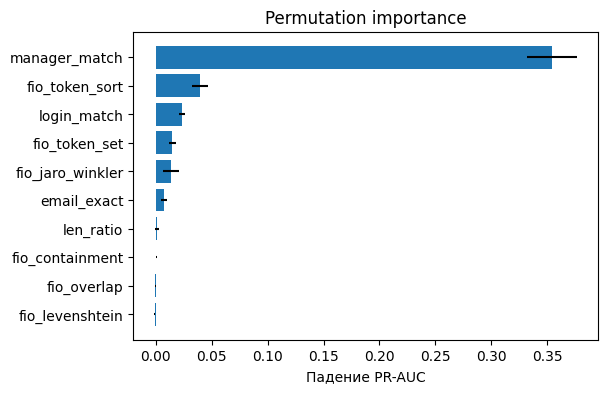

In [6]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(models[best], X_te, y_te, n_repeats=20,
                              random_state=42, scoring='average_precision')
order = np.argsort(perm.importances_mean)
plt.figure(figsize=(6,4))
plt.barh([names[i] for i in order], perm.importances_mean[order],
         xerr=perm.importances_std[order])
plt.xlabel('Падение PR-AUC'); plt.title('Permutation importance'); plt.show()

`manager_match` - сильнейший сигнал: совпадение руководителя разводит
однофамильцев. Дальше - сходство ФИО и логин. Это интерпретируемо и согласуется
с тем, как человек вручную разрешал бы неоднозначности.

## 7. Выбор порога под бизнес-режим

Для HR-данных цена ложного слияния двух людей выше цены ручной проверки.
Поэтому считаем два порога:
- **precision-first** (precision >= 0.99) - для авто-привязки;
- **max-F1** - сбалансированный, для полуавтоматического режима.

In [7]:
from sklearn.metrics import precision_score, recall_score
prec, rec, thr = precision_recall_curve(y_te, p_cal)
ok = np.where(prec[:-1] >= 0.99)[0]
thr_p = thr[ok[0]] if len(ok) else 0.5
f1s = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9)
thr_f1 = thr[np.argmax(f1s)]
for name,t in [('precision>=0.99',thr_p),('max F1',thr_f1)]:
    pred = (p_cal>=t).astype(int)
    print(f'{name:16s} thr={t:.3f}  P={precision_score(y_te,pred):.3f} '
          f'R={recall_score(y_te,pred):.3f}')

precision>=0.99  thr=0.969  P=0.994 R=0.648
max F1           thr=0.697  P=0.966 R=0.962


## 8. Инференс на реальных данных задания

Применяем обученную модель к новым парам. Берём запись без email и без отчества (как в реальных отчётах ЭРА/SkillCode) и сравниваем с кандидатами, среди которых есть однофамилец.

In [8]:
# Применение модели к новым парам (самодостаточно, без пайплайна)
import joblib, json
from features import pair_features
model = joblib.load("models/matcher_model.joblib")
card = json.load(open("models/model_card.json", encoding="utf-8"))
thr = card["threshold_precision_099"]

def score(rec, emp):
    return float(model.predict_proba([pair_features(*rec, *emp)])[0,1])

record = ("абызов евгений", "", "", "")   # из отчёта: нет email и отчества
for emp in [
    ("абызов евгений игоревич", "abyzov.e@company.ru", "abyzov.e", ""),
    ("абызов евгений олегович", "abyzov.eo@company.ru", "abyzov.eo", ""),  # однофамилец
    ("кузнецова екатерина андреевна", "kuznecova.e@company.ru", "", ""),
]:
    p = score(record, emp)
    verdict = "СВЯЗАТЬ" if p>=thr else ("ручная проверка" if p>=0.5 else "не связывать")
    print(f"{emp[0]:<32} p={p:.2f} -> {verdict}")

абызов евгений игоревич          p=0.71 -> ручная проверка
абызов евгений олегович          p=0.71 -> ручная проверка
кузнецова екатерина андреевна    p=0.01 -> не связывать


Два однофамильца Абызовых получают одинаково среднюю вероятность - модель не может выбрать между ними без отчества или руководителя и отправляет на ручную проверку. Не относящийся к делу кандидат отвергается. Это и есть нужное поведение: **лучше отдать на проверку человеку, чем ошибочно слить два профиля.**

**Итого:** обучаемый классификатор пар с hard negatives, калибровкой вероятностей и порогом под бизнес-режим - ML-решение задачи матчинга из ТЗ.